In [11]:
"""
Presentation-quality plots for NegBin hierarchical model results.
Mixed audience — uses plain language, IRR scale, % annotations.
"""

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

from analysis.utils import style

In [12]:
# ── Load summary ──────────────────────────────────────────────────────────────
bambi_summary = pd.read_csv("../bambi_outputs/bambi_summary_0.csv", index_col="parameter")
bambi_summary.index = bambi_summary.index.astype(str)

# ── Helpers ───────────────────────────────────────────────────────────────────
def extract_group(summary, pattern):
    mask = summary.index.str.contains(pattern, regex=True)
    return summary[mask].copy()

def parse_level(idx_str, pattern):
    """Pull the level name out of a parameter string like C(epoch, ...)[Alpha]."""
    m = re.search(pattern, idx_str)
    return m.group(1) if m else idx_str

# ── SIMD ──────────────────────────────────────────────────────────────────────
simd_df = extract_group(bambi_summary, r"simd_quintile_mode")
simd_df["quintile"] = simd_df.index.map(
    lambda s: int(parse_level(s, r"\[(\d)\]"))
)

# Ensure we always plot all five quintiles, inserting Q3 as the model reference.
simd_template = pd.DataFrame({"quintile": [1, 2, 3, 4, 5]})
simd_df = simd_template.merge(
    simd_df[["quintile", "mean", "hdi_3%", "hdi_97%"]],
    on="quintile",
    how="left",
)
simd_df.loc[simd_df["quintile"] == 3, ["mean", "hdi_3%", "hdi_97%"]] = 0.0
simd_df["label"] = simd_df["quintile"].map(lambda q: f"Q{q}")
simd_df.loc[simd_df["quintile"] == 3, "label"] = "Q3\n(reference)"

# ── Epoch ─────────────────────────────────────────────────────────────────────
epoch_df = extract_group(bambi_summary, r"epoch")
epoch_df["label"] = epoch_df.index.map(
    lambda s: parse_level(s, r"\[(.+?)\]")
)
ref_epoch = pd.DataFrame(
    {"mean": [0.0], "hdi_3%": [0.0], "hdi_97%": [0.0], "label": ["Delta\n(reference)"]},
    index=["reference_epoch"],
)
epoch_df = pd.concat([ref_epoch, epoch_df]).reset_index(drop=True)

# ── Random effects ────────────────────────────────────────────────────────────
re_df = extract_group(bambi_summary, r"1\|window_id\[")
re_df["label"] = re_df.index.map(
    lambda s: parse_level(s, r"\[(.+?)\]")
)
re_df = re_df.rename(columns={"mean": "mean", "hdi_3%": "lo", "hdi_97%": "hi"})
re_df = re_df.sort_values("mean").reset_index(drop=True)

# ── Convergence ───────────────────────────────────────────────────────────────
conv_df = bambi_summary.dropna(subset=["r_hat"]).copy()
conv_df = conv_df[~conv_df.index.str.contains(r"1\|window_id\[")]  # drop individual REs

# ── IRR transform (for simd / epoch) ─────────────────────────────────────────
for df in [simd_df, epoch_df]:
    df["irr"] = np.exp(df["mean"])
    df["lo"]  = np.exp(df["hdi_3%"])
    df["hi"]  = np.exp(df["hdi_97%"])
    df["pct"] = (df["irr"] - 1) * 100
    df["is_ref"] = df["mean"] == 0.0
    df["sig"]    = (~df["is_ref"]) & (~((df["lo"] <= 1.0) & (df["hi"] >= 1.0)))

re_df["sig"] = ~((re_df["lo"] <= 0) & (re_df["hi"] >= 0))
re_df["pos"] = re_df["mean"] > 0

Fig 1 saved.
Fig 2 saved.
Fig 3 saved.
Fig 4 saved.


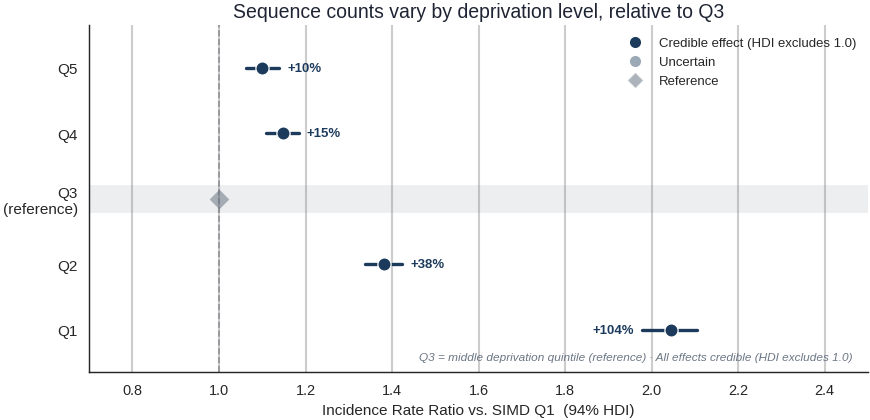

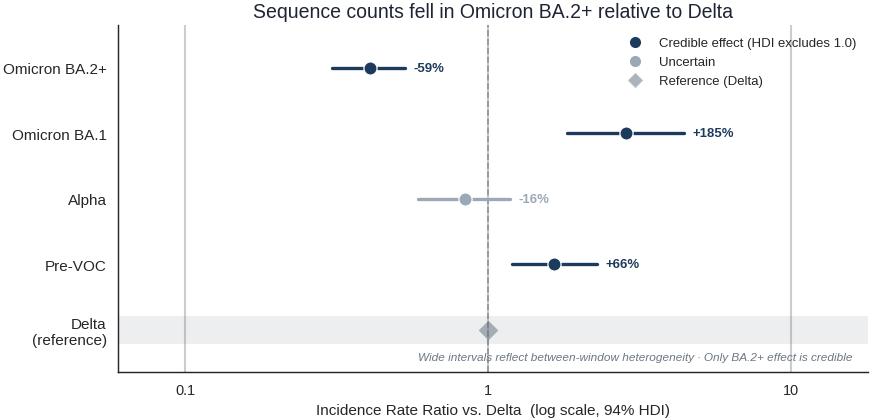

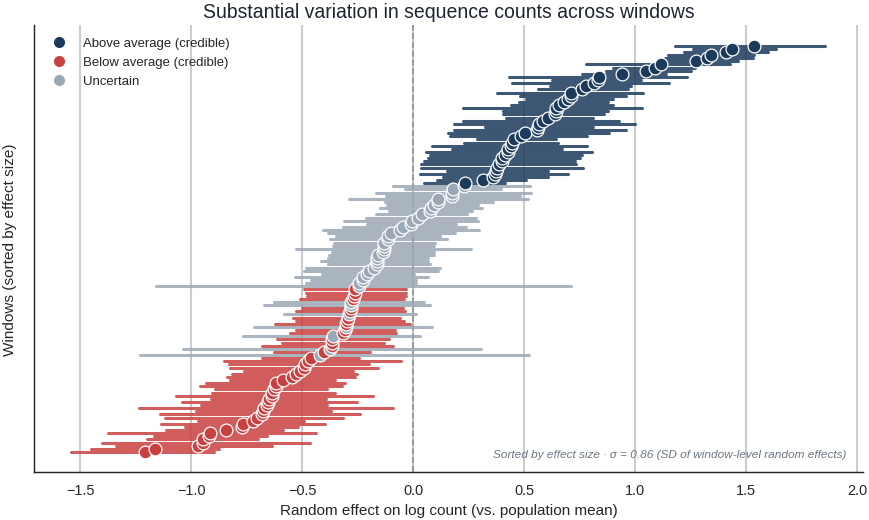

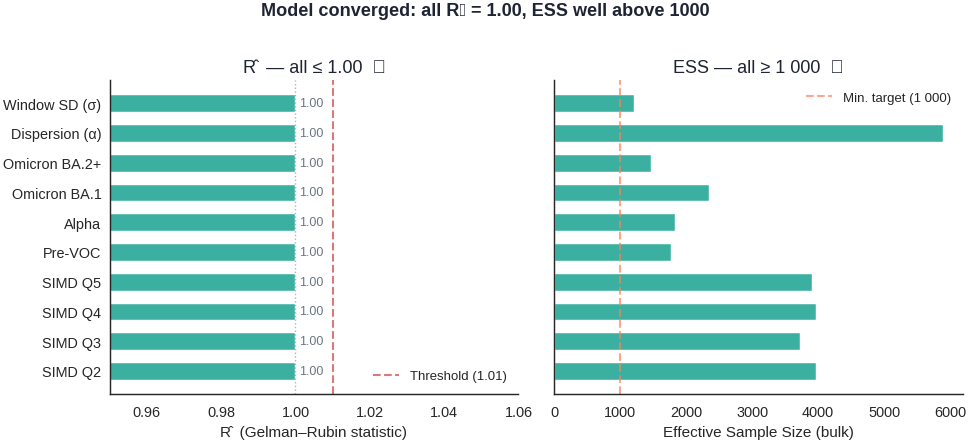

In [17]:
style.set_theme(context="talk")

# ── Palette & style ───────────────────────────────────────────────────────────
C = dict(
    navy    = "#1B3A5C",
    blue    = "#2D7DD2",
    teal    = "#3BB0A0",
    orange  = "#F4845F",
    red     = "#C94040",
    grey    = "#9BA8B5",
    midgrey = "#6B7684",
    text    = "#1E2433",
    bg      = "#FFFFFF",
    strip   = "#F5F7FA",
    grid    = "#E2E8F0",
)


# ── Helper: draw one forest row ───────────────────────────────────────────────
def forest_row(ax, i, irr, lo, hi, pct, is_ref, sig,
               xlim_hi=None, log_scale=False):
    if is_ref:
        ax.scatter(irr, i, s=100, color=C["midgrey"], zorder=5, marker="D",
                   linewidths=0, alpha=0.55)
        ax.axhline(i, color=C["midgrey"], alpha=0.12, lw=20, zorder=1)
        return

    col  = C["navy"] if sig else C["grey"]
    ecol = "#FFFFFF"
    lw   = 2.4

    # CI line
    ax.plot([lo, hi], [i, i], color=col, lw=lw,
            solid_capstyle="round", zorder=3)
    # Point
    ax.scatter(irr, i, s=90, color=col, zorder=5,
               edgecolors=ecol, linewidth=0.9)

    # % annotation
    sign = "+" if pct > 0 else ""
    label = f"{sign}{pct:.0f}%"
    if xlim_hi and hi > xlim_hi * 0.80:
        ax.annotate(label, xy=(lo, i), xytext=(-6, 0),
                    textcoords="offset points",
                    va="center", ha="right",
                    fontsize=9.5, color=col, fontweight="bold")
    else:
        ax.annotate(label, xy=(hi, i), xytext=(6, 0),
                    textcoords="offset points",
                    va="center", ha="left",
                    fontsize=9.5, color=col, fontweight="bold")


def style_forest_ax(ax, df, ref_x=1.0, log_scale=False):
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["label"], fontsize=11)
    ax.axvline(ref_x, color=C["text"], lw=1.2, ls="--", alpha=0.35, zorder=2)
    ax.grid(axis="x")
    ax.grid(axis="y", alpha=0)
    ax.tick_params(axis="y", length=0, pad=8)
    ax.set_ylim(-0.65, len(df) - 0.35)
    if log_scale:
        ax.set_xscale("log")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — SIMD Quintile Effects
# ═══════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(9, 4.5))

xlim = (0.70, 2.5)
for i, row in simd_df.iterrows():
    forest_row(ax, i, row.irr, row.lo, row.hi, row.pct,
               row.is_ref, row.sig, xlim_hi=xlim[1])

style_forest_ax(ax, simd_df)
ax.set_xlim(*xlim)
ax.set_xlabel("Incidence Rate Ratio vs. SIMD Q1  (94% HDI)", fontsize=11)
ax.set_title(
    "Sequence counts vary by deprivation level, relative to Q3",
    fontsize=14, color=C["text"],
)

# Subtitle / annotation block
ax.text(0.98, 0.03,
        "Q3 = middle deprivation quintile (reference) · All effects credible (HDI excludes 1.0)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8.5, color=C["midgrey"], style="italic")

# Legend
legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["navy"],
           markersize=9, label="Credible effect (HDI excludes 1.0)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["grey"],
           markersize=9, label="Uncertain"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=C["midgrey"],
           markersize=8, alpha=0.55, label="Reference"),
]
ax.legend(handles=legend_els, loc="upper right", fontsize=9.5)

fig1.tight_layout()
fig1.savefig("fig1_simd.png")
print("Fig 1 saved.")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Epoch Effects  (log IRR scale — wide CIs need it)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(9, 4.5))

for i, row in epoch_df.iterrows():
    irr = row.irr if not row.is_ref else 1.0
    lo  = row.lo  if not row.is_ref else 1.0
    hi  = row.hi  if not row.is_ref else 1.0
    forest_row(ax, i, irr, lo, hi, row.pct,
               row.is_ref, row.sig, log_scale=True)

style_forest_ax(ax, epoch_df, log_scale=True)

ax.set_xlim(0.06, 18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Incidence Rate Ratio vs. Delta  (log scale, 94% HDI)", fontsize=11)
ax.set_title(
    "Sequence counts fell in Omicron BA.2+ relative to Delta",
    fontsize=14, color=C["text"],
)
ax.text(0.98, 0.03,
        "Wide intervals reflect between-window heterogeneity · Only BA.2+ effect is credible",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8.5, color=C["midgrey"], style="italic")

legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["navy"],
           markersize=9, label="Credible effect (HDI excludes 1.0)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["grey"],
           markersize=9, label="Uncertain"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=C["midgrey"],
           markersize=8, alpha=0.55, label="Reference (Delta)"),
]
ax.legend(handles=legend_els, loc="upper right", fontsize=9.5)

fig2.tight_layout()
fig2.savefig("fig2_epoch.png")
print("Fig 2 saved.")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Random Effects (caterpillar, sorted)
# ═══════════════════════════════════════════════════════════════════════════════
fig3, ax = plt.subplots(figsize=(9, 5.5))

for i, row in re_df.iterrows():
    if row.sig:
        col = C["navy"] if row.pos else C["red"]
    else:
        col = C["grey"]

    ax.plot([row.lo, row.hi], [i, i], color=col, lw=2.2,
            solid_capstyle="round", zorder=3, alpha=0.85)
    ax.scatter(row["mean"], i, s=85, color=col, zorder=5,
               edgecolors="white", linewidth=0.9)

ax.axvline(0, color=C["text"], lw=1.2, ls="--", alpha=0.35, zorder=2)
ax.set_yticks(range(len(re_df)))
ax.set_yticklabels([])
# ax.tick_params(axis="y", length=0, pad=8)
# ax.set_ylim(-0.65, len(re_df) - 0.35)
ax.set_ylabel("Windows (sorted by effect size)", fontsize=11)
ax.set_xlabel("Random effect on log count (vs. population mean)", fontsize=11)
ax.set_title(
    "Substantial variation in sequence counts across windows",
    fontsize=14, color=C["text"],
)
ax.text(0.98, 0.03,
        "Sorted by effect size · σ = 0.86 (SD of window-level random effects)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8.5, color=C["midgrey"], style="italic")

legend_els = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["navy"],
           markersize=9, label="Above average (credible)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["red"],
           markersize=9, label="Below average (credible)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["grey"],
           markersize=9, label="Uncertain"),
]
ax.legend(handles=legend_els, loc="upper left", fontsize=9.5)
ax.grid(axis="x")
ax.grid(axis="y", alpha=0)

fig3.tight_layout()
fig3.savefig("fig3_random_effects.png")
print("Fig 3 saved.")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Convergence summary (R-hat + ESS)
# ═══════════════════════════════════════════════════════════════════════════════
conv_data = {
    "parameter": [
        "SIMD Q2", "SIMD Q3", "SIMD Q4", "SIMD Q5",
        "Pre-VOC", "Alpha", "Omicron BA.1", "Omicron BA.2+",
        "Dispersion (α)", "Window SD (σ)",
    ],
    "r_hat":   [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    "ess_bulk":[3964, 3719, 3961, 3909, 1768, 1839, 2342, 1473, 5896, 1213],
}
conv_df = pd.DataFrame(conv_data)

fig4, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig4.suptitle("Model converged: all R̂ = 1.00, ESS well above 1000",
              fontsize=13, fontweight="bold", color=C["text"], y=1.01)

# — R-hat panel
ax = axes[0]
cols = [C["teal"] if r <= 1.01 else C["red"] for r in conv_df["r_hat"]]
bars = ax.barh(conv_df["parameter"], conv_df["r_hat"], color=cols,
               edgecolor="white", height=0.6)
ax.axvline(1.01, color=C["red"], lw=1.5, ls="--", alpha=0.7, label="Threshold (1.01)")
ax.axvline(1.00, color=C["text"], lw=1.0, ls=":", alpha=0.35)
ax.set_xlim(0.95, 1.06)
ax.set_xlabel("R̂  (Gelman–Rubin statistic)", fontsize=11)
ax.set_title("R̂  — all ≤ 1.00  ✓", color=C["text"])
ax.legend(fontsize=9.5, loc="lower right")
ax.tick_params(axis="y", length=0, pad=6)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{w:.2f}", va="center", ha="left", fontsize=9, color=C["midgrey"])

# — ESS panel
ax = axes[1]
ess_cols = [C["teal"] if e >= 1000 else C["orange"] for e in conv_df["ess_bulk"]]
ax.barh(conv_df["parameter"], conv_df["ess_bulk"], color=ess_cols,
        edgecolor="white", height=0.6)
ax.axvline(1000, color=C["orange"], lw=1.5, ls="--", alpha=0.7, label="Min. target (1 000)")
ax.set_xlabel("Effective Sample Size (bulk)", fontsize=11)
ax.set_title("ESS — all ≥ 1 000  ✓", color=C["text"])
ax.legend(fontsize=9.5)
ax.tick_params(axis="y", length=0, pad=6)
ax.set_yticklabels([])

fig4.tight_layout()
fig4.savefig("fig4_convergence.png")
print("Fig 4 saved.")